In [6]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker
project_root = Path().resolve().parent

In [7]:
df_full = pd.read_csv(project_root / "data/cleaned.csv")
#df_full = df_full.drop(columns="kmeans")
df = df_full.drop(columns=["transaction_month", "amounts.shares", "amounts.pricePerShare", "filing_count_reportingOwner.name", "trades_14d", "holding_change_percent"])
non_str = df.select_dtypes(include=["number", "bool"]).columns
non_day = [c for c in non_str if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df = df[non_day]
df

,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,month_sin,month_cos,high_frequency_trader,high_price,high_change_in_holdings,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans
0,False,True,False,1,5.000000e-01,0.866025,0,0,1,14.810847,2.800167,1.682722,-0.495984,-0.639443,0
1,False,False,True,0,5.000000e-01,0.866025,0,0,0,12.763522,2.349076,-0.534718,-0.487419,-0.639443,0
2,False,False,True,0,5.000000e-01,0.866025,0,0,0,9.971760,2.357344,-0.949839,-0.487419,-0.565800,1
3,False,False,True,0,5.000000e-01,0.866025,0,0,0,10.613207,2.340755,-0.879243,-0.487419,-0.492157,0
4,False,True,False,1,5.000000e-01,0.866025,0,0,1,9.024040,2.269244,1.074058,-0.547370,-0.639443,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97149,True,True,False,1,-2.449294e-16,1.000000,1,0,0,4.873516,2.724795,-0.828549,0.159188,-0.713086,1
97150,True,True,False,1,-2.449294e-16,1.000000,1,0,1,11.808925,2.727904,1.346064,0.159188,-0.713086,0
97151,False,False,True,0,-2.449294e-16,1.000000,1,1,0,2.210827,4.251506,-1.188667,2.150396,-0.713086,1
97152,False,False,True,0,-2.449294e-16,1.000000,1,1,0,9.045543,4.260137,-0.732465,2.150396,-0.639443,1


In [8]:
X = df.values
idx = np.random.choice(len(X), 20_000, replace=False)
X_sub = X[idx]
silhouettes = []
for k in range(2, 11):
    km = MiniBatchKMeans(
        n_clusters=k,
        n_init=5,
        batch_size=2048,
        random_state=42
    )
    labels = km.fit_predict(X)
    silhouettes.append(silhouette_score(X_sub, labels[idx]))

silhouettes

[0.4072399749349601,
 0.28639029581932735,
 0.23034193907195266,
 0.22506300463599563,
 0.17006764489161538,
 0.18142863062447104,
 0.1649777252670173,
 0.15411990121181332,
 0.14839057023678592]

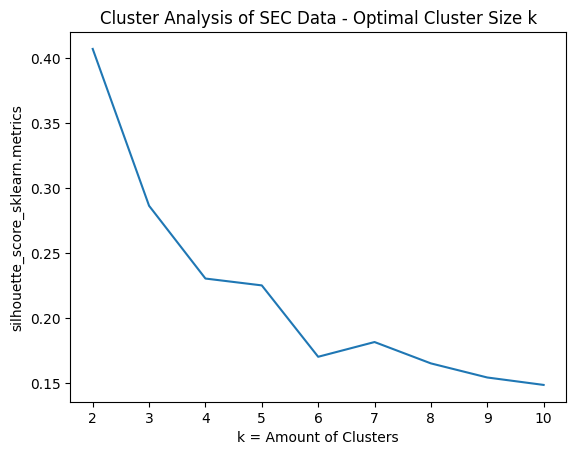

In [12]:
ys = silhouettes
xs = [x for x in range(2, 11)]

plt.plot(xs, ys)
plt.title("Cluster Analysis of SEC Data - Optimal Cluster Size k")
plt.xlabel("k = Amount of Clusters")
plt.ylabel("silhouette_score_sklearn.metrics")
plt.savefig(project_root / 'exports/clustera_analysis_silhouette_scores.png', dpi=500)
plt.show()


In [13]:
kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    n_init=30,
    random_state=42
)

feature_cols = df.columns

df["kmeans"] = kmeans.fit_predict(X)

cluster_centers = (
    pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
      .assign(cluster=lambda d: d.index)
)

cluster_centers
cluster_centers.to_csv(project_root / 'cluster_centers.csv', index=False)


In [14]:
df.groupby("kmeans").size()

kmeans
0    50106
1    47048
dtype: int64

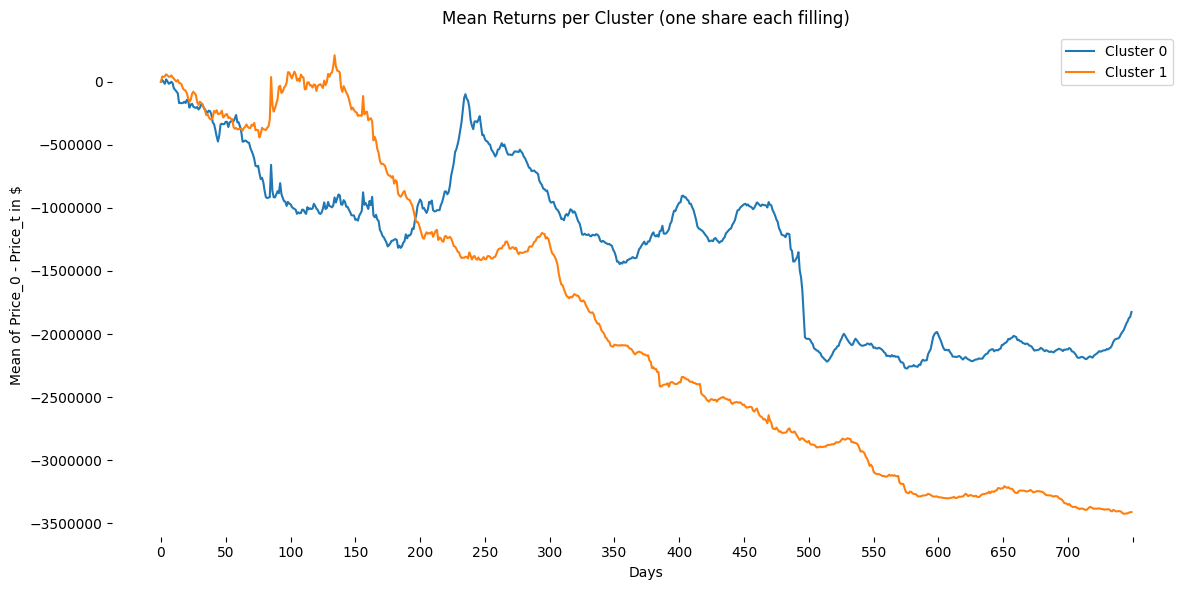

In [15]:
day_cols = [str(i) for i in range(0, 750)]
return_df = df_full[day_cols].copy()
return_df['kmeans'] = df['kmeans']

x_0 = return_df['0'].to_numpy()[:, None]
Xt = return_df[day_cols].to_numpy()
return_matrix = Xt - x_0
return_df = pd.DataFrame(return_matrix, columns=day_cols)
return_df['kmeans'] = df['kmeans'].values

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cluster in sorted(return_df['kmeans'].unique()):
    cluster_mean = return_df[return_df['kmeans'] == cluster].mean().iloc[:-1]
    ax.plot(cluster_mean, label=f'Cluster {cluster}')

ax.set_title('Mean Returns per Cluster (one share each filling)')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t in $')
ax.legend()
ax.ticklabel_format(style='plain', axis='y')
for s in ax.spines.values():
    s.set_visible(False)

ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.tight_layout()
plt.savefig(project_root / 'exports/mean_of_return_per_cluster.png', dpi=500)
plt.show()

In [19]:
# # Percent Mean Returns for each cluster one share each filling
# day_cols = [str(i) for i in range(0, 750)]
# return_df = df_full[day_cols].copy()
# return_df['kmeans'] = df['kmeans']

# x_0 = return_df['0'].to_numpy()[:, None]
# Xt = return_df[day_cols].to_numpy()
# eps = 1e-2  # Increase this to avoid extreme values from near-zero prices
# return_matrix = ((Xt - x_0) / (np.abs(x_0) + eps)) * 100
# return_df = pd.DataFrame(return_matrix, columns=day_cols)
# return_df['kmeans'] = df['kmeans'].values

# x_0 = return_df['0'].to_numpy()[:, None]
# Xt = return_df[day_cols].to_numpy()
# eps = 1e-8
# return_matrix = ((Xt - x_0) / (x_0 + eps)) * 100
# return_df = pd.DataFrame(return_matrix, columns=day_cols)
# return_df['kmeans'] = df['kmeans'].values

# fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# for cluster in sorted(return_df['kmeans'].unique()):
#     cluster_mean = return_df[return_df['kmeans'] == cluster].mean().iloc[:-1]
#     ax.plot(cluster_mean, label=f'Cluster {cluster}')

# ax.set_title('Percent Mean Returns for each cluster one share each filling')
# ax.set_xlabel('Days')
# ax.set_ylabel('Percent')
# ax.legend()
# ax.ticklabel_format(style='plain', axis='y')
# for s in ax.spines.values():
#     s.set_visible(False)

# ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
# plt.tight_layout()
# plt.show()


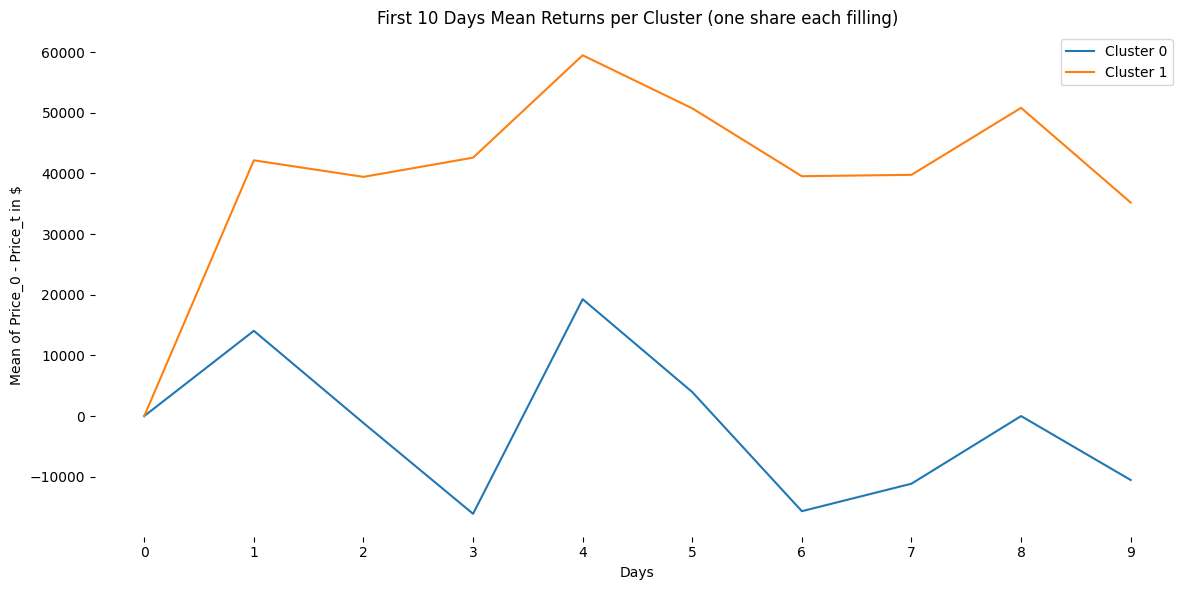

In [16]:
# Mean Returns for each cluster one share each filling
day_cols = [str(i) for i in range(0, 10)]
return_df = df_full[day_cols].copy()
return_df['kmeans'] = df['kmeans']

x_0 = df_full['0'].to_numpy()[:, None]
Xt = return_df[day_cols].to_numpy()
return_matrix = Xt - x_0
return_df = pd.DataFrame(return_matrix, columns=day_cols)
return_df['kmeans'] = df['kmeans'].values

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cluster in sorted(return_df['kmeans'].unique()):
    cluster_mean = return_df[return_df['kmeans'] == cluster].mean().iloc[:-1]
    ax.plot(cluster_mean, label=f'Cluster {cluster}')

ax.set_title('First 10 Days Mean Returns per Cluster (one share each filling)')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t in $')
ax.legend()
ax.ticklabel_format(style='plain', axis='y')
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(project_root / 'exports/mean_of_return_per_cluster_10d.png', dpi=500)
plt.show()

In [17]:
df_full['kmeans'] = df['kmeans'].values
df_full

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,...,746,747,748,749,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans
0,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,True,False,1,...,3.611793,3.626802,3.618046,3.629302,14.810847,2.800167,1.682722,-0.495984,-0.639443,1
1,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,False,True,0,...,13.015418,13.015418,12.986280,13.025130,12.763522,2.349076,-0.534718,-0.487419,-0.639443,1
2,WLFC,JACOBS SY,2009-01-29,613.0,8.6600,I,False,False,True,0,...,13.015418,12.986280,13.025130,13.034844,9.971760,2.357344,-0.949839,-0.487419,-0.565800,0
3,WLFC,JACOBS SY,2009-01-30,808.0,8.5400,I,False,False,True,0,...,12.986280,13.025130,13.034844,13.073694,10.613207,2.340755,-0.879243,-0.487419,-0.492157,1
4,HXL,HENNEMUTH ROBERT,2009-01-30,400.0,8.0400,D,False,True,False,1,...,18.959692,18.895298,18.922897,19.033287,9.024040,2.269244,1.074058,-0.547370,-0.639443,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97149,SPE,GOLDSTEIN PHILLIP,2023-12-28,44.0,11.7500,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,4.873516,2.724795,-0.828549,0.159188,-0.713086,0
97150,SPE,GOLDSTEIN PHILLIP,2023-12-28,1319.0,11.7800,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,11.808925,2.727904,1.346064,0.159188,-0.713086,1
97151,SFBC,STILWELL JOSEPH,2023-12-28,7.0,38.7500,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,2.210827,4.251506,-1.188667,2.150396,-0.713086,0
97152,SFBC,STILWELL JOSEPH,2023-12-29,404.0,39.0000,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,9.045543,4.260137,-0.732465,2.150396,-0.639443,0


In [22]:
df_full.to_csv(project_root / "data/cleaned.csv", index=False)